# Loading in the models

In [ ]:
# imports
import torch
import torch.nn as nn
import torchvision.models as models

from google.colab import drive
# mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


NOTE: <br>
* adjust path to match where the pth files are
* adjust the cpu/gpu depending on using cpu or gpu (map_location)

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/models/best_efficientnet_b0.pth', map_location='cpu')
print(checkpoint.keys())

print(checkpoint['class_names'])   # class names
print(checkpoint['label_to_idx'])  # class name to index mapping

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/models/best_efficientnet_b0.pth'

In [ ]:
LABEL_COLS = checkpoint['class_names']

In [ ]:
# loading EfficientNet
checkpoint = torch.load('/content/drive/MyDrive/models/best_efficientnet_b0.pth', map_location='cpu')
efficientnet = models.efficientnet_b0()
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, len(LABEL_COLS))
efficientnet.load_state_dict(checkpoint['model_state_dict'])
efficientnet.eval()

In [ ]:
# loading ResNet
checkpoint = torch.load('/content/drive/MyDrive/models/resnet.pth', map_location='cpu')

resnet = models.resnet18()
resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(resnet.fc.in_features, len(LABEL_COLS))
)
resnet.load_state_dict(checkpoint)
resnet.eval()

In [ ]:
# loading shufflenet
checkpoint = torch.load('/content/drive/MyDrive/models/best_shufflenet_v2_single_label.pth', map_location='cpu')

shufflenet = models.shufflenet_v2_x1_0()
shufflenet.fc = nn.Linear(shufflenet.fc.in_features, len(LABEL_COLS))
shufflenet.load_state_dict(checkpoint)
shufflenet.eval()

In [ ]:
# using normal averaging (1/3 efficientnet, 1/3 resnet, 1/3 shufflenet)
class AverageEnsemble(nn.Module):
    # taking all three of the models inputs and storing their attributes
    def __init__(self, model1, model2, model3):
        super().__init__()
        self.model1 = model1
        self.model2 = model2
        self.model3 = model3

    # forward pass, converting the logits into probabilities
    def forward(self, x):
        out1 = torch.softmax(self.model1(x), dim=1)
        out2 = torch.softmax(self.model2(x), dim=1)
        out3 = torch.softmax(self.model3(x), dim=1)
        return (out1 + out2 + out3) / 3 # averaging prob distributions

ensemble = AverageEnsemble(efficientnet, resnet, shufflenet) # building ensemble

Training dataset classes:
1. Normal
2. Diabetic retinopathy
3. Glaucoma
4. Cataract
5. Macular degeneration
6. Hypertensive retinopathy
7. Myopia



# Loading the dataset

In [ ]:
import os
import zipfile
from pathlib import Path
import pandas as pd
import gdown
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# same transformations are the training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# obtaining the testing dataset
folder_link = "https://drive.google.com/drive/folders/1NO7LASTtbYvfE6-2lKGp2rAJXiSISHee?usp=sharing"
download_folder = "/content/gdrive_public"
os.makedirs(download_folder, exist_ok=True)

result = gdown.download_folder(
    url = folder_link,
    output = download_folder,
    quiet = False,
    use_cookies = False
)

# saving the files
images_zip, train_data_csv, val_data_csv = result

# unzip images
extract_dir = "/content/gdrive_public/images"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(images_zip, "r") as zip_ref:
  zip_ref.extractall(extract_dir)

Retrieving folder contents


Processing file 11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ images.zip
Processing file 1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm train_data_8.csv
Processing file 1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix- val_data_8.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ
From (redirected): https://drive.google.com/uc?id=11nJZrKAhepO_zZ5Ef15QADsIG39y4lzZ&confirm=t&uuid=79900ff7-f859-45c9-a29e-0a4e6b8280dc
To: /content/gdrive_public/images.zip
100%|██████████| 5.44G/5.44G [01:25<00:00, 63.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xtDYMkkr20Xm4FDxV4FHIhrJ8-A-tImm
To: /content/gdrive_public/train_data_8.csv
100%|██████████| 80.1k/80.1k [00:00<00:00, 26.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lYk5996KZ7DEHDirKlrbWHoTvkvt2ix-
To: /content/gdrive_public/val_data_8.csv
100%|██████████| 20.1k/20.1k [00:00<00:00, 19.3MB/s]
Download completed


Crop_black_borders is used to crop the test images, similar to our preprocessing with the training images

In [ ]:
def crop_black_borders(image):
    img_np = np.array(image)
    black_threshold = 10

    non_black_pixels = np.any(img_np > black_threshold, axis=2)
    rows = np.any(non_black_pixels, axis=1)
    cols = np.any(non_black_pixels, axis=0)

    if not rows.any() or not cols.any():
        return image

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    cropped_img_np = img_np[rmin:rmax + 1, cmin:cmax + 1]
    return Image.fromarray(cropped_img_np)

In [ ]:
# checking the images within extract_dir
all_images = list(Path(extract_dir).rglob("*"))

# combine the train and validation set into one
temp_df = pd.concat([pd.read_csv(train_data_csv), pd.read_csv(val_data_csv)], ignore_index=True)

# adding image path to temp_df
image_path_map = {
    Path(p).stem: str(p)
    for p in all_images
}

test_df = temp_df.copy()
test_df["image_path"] = test_df["ID"].astype(str).map(image_path_map)

# remove ID column from df
test_df.drop(columns=["ID"], inplace=True)

# Preprocessing test set

In [ ]:
# only keeping the class labels that match with our training labels
test_df = test_df[['image_path', 'NORMAL', 'DR', 'OTHER', 'ARMD', 'HTR', 'MYA']]

In [ ]:
print(test_df)

                                             image_path  NORMAL  DR  OTHER  \
0     /content/gdrive_public/images/images/aria_c_25...       1   0      0   
1     /content/gdrive_public/images/images/aria_c_7_...       1   0      0   
2     /content/gdrive_public/images/images/aria_c_38...       1   0      0   
3     /content/gdrive_public/images/images/aria_c_2_...       1   0      0   
4     /content/gdrive_public/images/images/aria_c_26...       1   0      0   
...                                                 ...     ...  ..    ...   
2203    /content/gdrive_public/images/images/im0373.png       0   0      0   
2204    /content/gdrive_public/images/images/im0377.png       0   0      0   
2205    /content/gdrive_public/images/images/im0397.png       0   0      0   
2206    /content/gdrive_public/images/images/im0399.png       0   0      1   
2207    /content/gdrive_public/images/images/im0402.png       0   0      0   

      ARMD  HTR  MYA  
0        0    0    0  
1        0    0  

In [ ]:
# converting the dataframe to the Dataset class
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# getting the image using the image path
# since dataframe contains image paths
class ImagePathDataset(Dataset):
    def __init__(self, df, image_col, label_cols, transform=None):
        self.df = df
        self.image_col = image_col
        self.label_cols = label_cols  # list of one-hot columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df[self.image_col].iloc[idx]).convert('RGB')
        # Convert one-hot row back to class index
        label = torch.tensor(self.df[self.label_cols].iloc[idx].values, dtype=torch.float32).argmax()
        if self.transform:
            image = self.transform(image)
        return image, label

# Ensemble defined

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/models/best_efficientnet_b0.pth', map_location='cpu')
print(checkpoint['class_names'])
print(checkpoint['label_to_idx'])

['HYPERTENSION', 'CATARACT', 'AGE_RELATED_MACULAR_DEGENERATION', 'GLAUCOMA', 'MYOPIA', 'DIABETIC_RETINOPATHY', 'NORMAL', 'OTHER_DISEASES']
{'HYPERTENSION': 0, 'CATARACT': 1, 'AGE_RELATED_MACULAR_DEGENERATION': 2, 'GLAUCOMA': 3, 'MYOPIA': 4, 'DIABETIC_RETINOPATHY': 5, 'NORMAL': 6, 'OTHER_DISEASES': 7}


In [ ]:
# ResNet
resnet_checkpoint = torch.load('/content/drive/MyDrive/models/resnet.pth', map_location='cpu')
resnet = models.resnet18()
resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(resnet.fc.in_features, len(LABEL_COLS))  # now 8
)
resnet.load_state_dict(resnet_checkpoint)
resnet.eval()

# ShuffleNet
shufflenet_checkpoint = torch.load('/content/drive/MyDrive/models/best_shufflenet_v2_single_label.pth', map_location='cpu')
shufflenet = models.shufflenet_v2_x1_0()
shufflenet.fc = nn.Linear(shufflenet.fc.in_features, len(LABEL_COLS))  # now 8
shufflenet.load_state_dict(shufflenet_checkpoint)
shufflenet.eval()

ShuffleNetV2(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
ensemble = AverageEnsemble(efficientnet, resnet, shufflenet) # rebuilding ensemble

In [ ]:
test_df = test_df.rename(columns={
    'DR'   : 'DIABETIC_RETINOPATHY',
    'OTHER': 'OTHER_DISEASES',
    'ARMD' : 'AGE_RELATED_MACULAR_DEGENERATION',
    'HTR'  : 'HYPERTENSION',
    'MYA'  : 'MYOPIA'
})

# update LABEL_COLS to match the test and training set columns
LABEL_COLS = ['NORMAL', 'HYPERTENSION', 'CATARACT', 'AGE_RELATED_MACULAR_DEGENERATION',
              'GLAUCOMA', 'MYOPIA', 'DIABETIC_RETINOPATHY', 'OTHER_DISEASES']

print(test_df.columns.tolist())  # verifying the columns names

['image_path', 'NORMAL', 'DIABETIC_RETINOPATHY', 'OTHER_DISEASES', 'AGE_RELATED_MACULAR_DEGENERATION', 'HYPERTENSION', 'MYOPIA']


In [ ]:
test_df['CATARACT'] = 0
test_df['GLAUCOMA'] = 0
# these two were not in the test dataset

In [ ]:
# loading the dataframe and creating dataloader
IMAGE_COL = 'image_path'
#LABEL_COLS = ['NORMAL', 'DR', 'OTHER', 'ARMD', 'HTR', 'MYA']

# same transformation as the training set
test_transform = transforms.Compose([
    transforms.Lambda(crop_black_borders),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# adjust the test_df.head(50) to test_df for the full test set
dataset = ImagePathDataset(test_df, image_col=IMAGE_COL, label_cols=LABEL_COLS, transform=test_transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Testing 1 image and demonstrating heatmap


Class Probabilities:
  NORMAL                              16.23%
  HYPERTENSION                        0.40%
  CATARACT                            0.64%
  AGE_RELATED_MACULAR_DEGENERATION    0.26%
  GLAUCOMA                            21.31%
  MYOPIA                              0.74%
  DIABETIC_RETINOPATHY                19.14%
  OTHER_DISEASES                      41.27%
Predicted Label : OTHER_DISEASES (41.27% confidence)
True Label      : NORMAL
Correct         : False


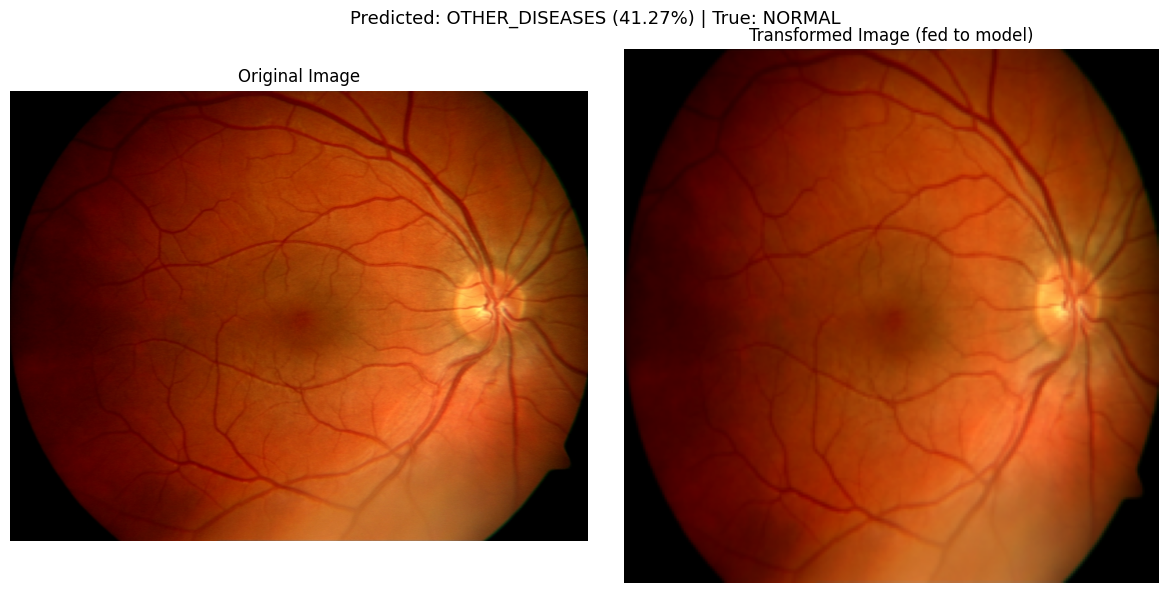

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# pick an image from the test set
sample_idx = 20  # change this to try different images
image_path = test_df[IMAGE_COL].iloc[sample_idx]
true_label = LABEL_COLS[test_df[LABEL_COLS].iloc[sample_idx].values.argmax()]

# load original image
original_image = Image.open(image_path).convert('RGB')

# apply transform and run through ensemble
input_tensor = test_transform(original_image).unsqueeze(0).to(device)

ensemble.eval()
with torch.no_grad():
    output = ensemble(input_tensor)
    pred_idx = output.argmax(dim=1).item()
    pred_label = LABEL_COLS[pred_idx]
    confidence = output[0][pred_idx].item() * 100

print("\nClass Probabilities:")
for label, prob in zip(LABEL_COLS, output[0].cpu().numpy()):
    print(f"  {label:<35} {prob*100:.2f}%")

# print results
print(f'Predicted Label : {pred_label} ({confidence:.2f}% confidence)')
print(f'True Label      : {true_label}')
print(f'Correct         : {pred_label == true_label}')

# convert transformed tensor back to viewable image
transformed_image = input_tensor.squeeze(0).cpu()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
transformed_image = (transformed_image * std + mean).clamp(0, 1)  # unnormalize
transformed_image = transformed_image.permute(1, 2, 0).numpy()    # CHW -> HWC

# show original and transformed side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image)
axes[0].axis('off')
axes[0].set_title('Original Image')

axes[1].imshow(transformed_image)
axes[1].axis('off')
axes[1].set_title('Transformed Image (fed to model)')

fig.suptitle(f'Predicted: {pred_label} ({confidence:.2f}%) | True: {true_label}', fontsize=13)
plt.tight_layout()
plt.show()

EfficientNet

EfficientNet Class Probabilities:
  NORMAL                              0.00%
  HYPERTENSION                        0.00%
  CATARACT                            0.00%
  AGE_RELATED_MACULAR_DEGENERATION    0.00%
  GLAUCOMA                            0.00%
  MYOPIA                              0.00%
  DIABETIC_RETINOPATHY                56.55% <-- Predicted
  OTHER_DISEASES                      43.44%

True Label: NORMAL


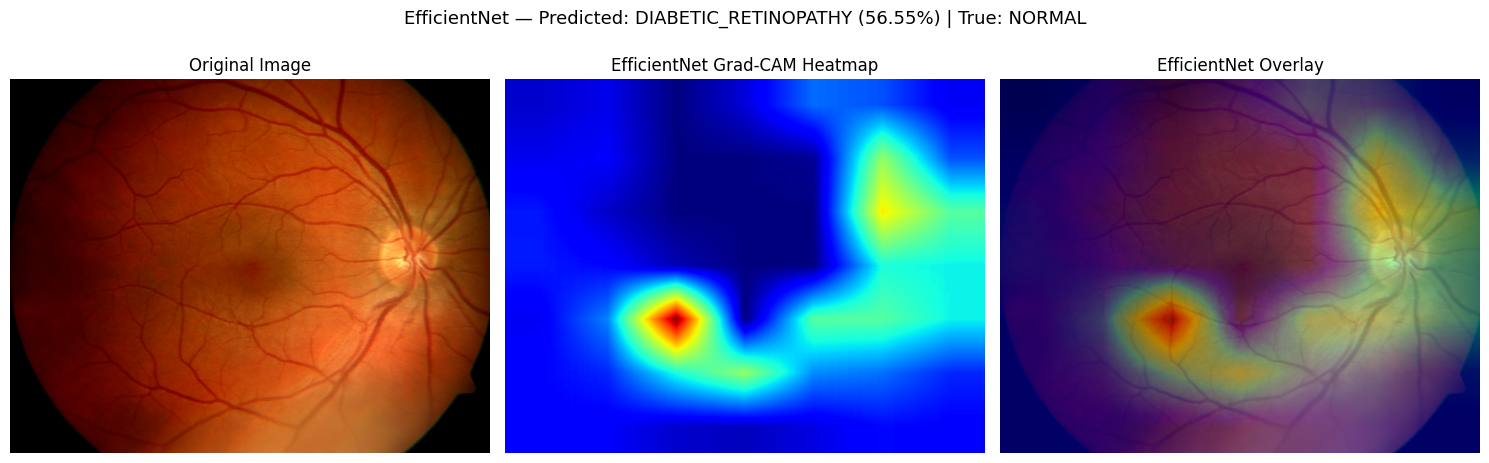

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def forward_hook(module, input, output):
    activations.append(output)

# register hooks with handles so they can be removed after
target_layer = ensemble.model1.features[-1]
forward_handle  = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# prepare image
original_image = Image.open(image_path).convert('RGB')
input_tensor = test_transform(original_image).unsqueeze(0).to(device)
input_tensor.requires_grad_()

# run only through efficientnet
ensemble.model1.eval()
output = torch.softmax(ensemble.model1(input_tensor), dim=1)
pred_idx = output.argmax(dim=1).item()

# print efficientnet probabilities
print("EfficientNet Class Probabilities:")
for label, prob in zip(LABEL_COLS, output[0].cpu().detach().numpy()):
    marker = " <-- Predicted" if label == LABEL_COLS[pred_idx] else ""
    print(f"  {label:<35} {prob*100:.2f}%{marker}")
print(f"\nTrue Label: {true_label}")

# backward pass
ensemble.model1.zero_grad()
output[0, pred_idx].backward()

# remove hooks immediately after use
forward_handle.remove()
backward_handle.remove()

# generate heatmap
gradient = gradients[0].cpu().detach().numpy()[0]
activation = activations[0].cpu().detach().numpy()[0]

weights = gradient.mean(axis=(1, 2))
heatmap = np.sum(weights[:, None, None] * activation, axis=0)
heatmap = np.maximum(heatmap, 0)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# resize heatmap to image size
heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize(
    original_image.size, Image.BILINEAR)) / 255.0

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image)
axes[0].axis('off')
axes[0].set_title('Original Image')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].axis('off')
axes[1].set_title('EfficientNet Grad-CAM Heatmap')

axes[2].imshow(original_image)
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
axes[2].axis('off')
axes[2].set_title('EfficientNet Overlay')

fig.suptitle(f'EfficientNet — Predicted: {LABEL_COLS[pred_idx]} ({output[0][pred_idx].item()*100:.2f}%) | True: {true_label}', fontsize=13)
plt.tight_layout()
plt.show()

ResNet

ResNet Class Probabilities:
  NORMAL                              0.00%
  HYPERTENSION                        0.00%
  CATARACT                            0.13%
  AGE_RELATED_MACULAR_DEGENERATION    0.00%
  GLAUCOMA                            61.12% <-- Predicted
  MYOPIA                              0.00%
  DIABETIC_RETINOPATHY                0.00%
  OTHER_DISEASES                      38.74%

True Label: NORMAL


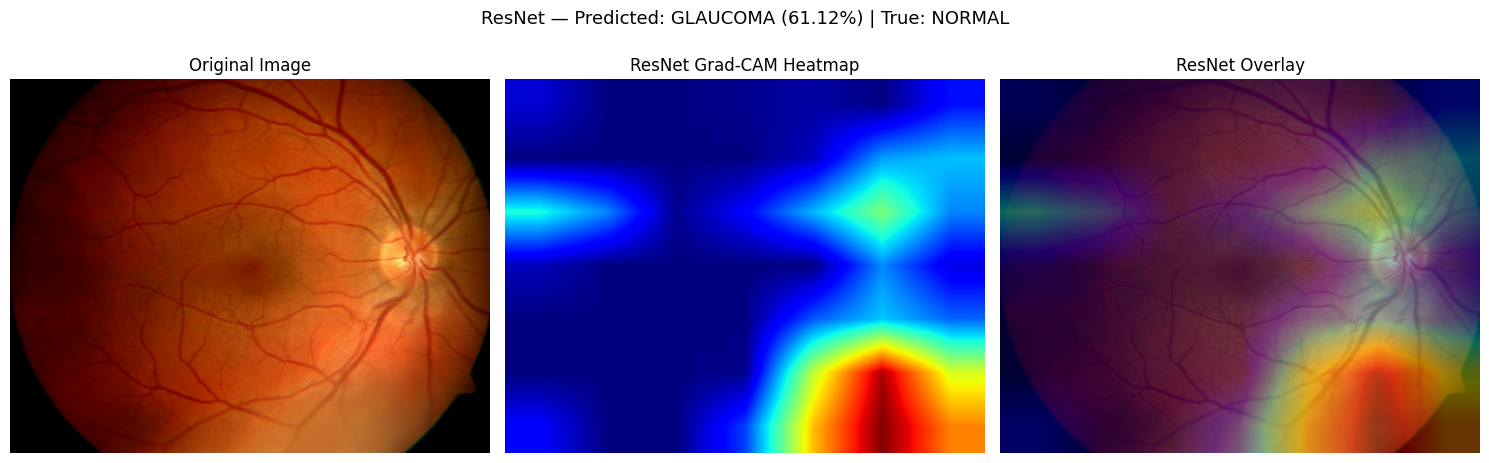

In [ ]:
gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def forward_hook(module, input, output):
    activations.append(output)

# register hooks with handles
target_layer = ensemble.model2.layer4[-1]
forward_handle  = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# prepare image
original_image = Image.open(image_path).convert('RGB')
input_tensor = test_transform(original_image).unsqueeze(0).to(device)
input_tensor.requires_grad_()

# run only through resnet
ensemble.model2.eval()
output = torch.softmax(ensemble.model2(input_tensor), dim=1)
pred_idx = output.argmax(dim=1).item()

# print resnet probabilities
print("ResNet Class Probabilities:")
for label, prob in zip(LABEL_COLS, output[0].cpu().detach().numpy()):
    marker = " <-- Predicted" if label == LABEL_COLS[pred_idx] else ""
    print(f"  {label:<35} {prob*100:.2f}%{marker}")
print(f"\nTrue Label: {true_label}")

# backward pass
ensemble.model2.zero_grad()
output[0, pred_idx].backward()

# remove hooks immediately after use
forward_handle.remove()
backward_handle.remove()

# generate heatmap
gradient = gradients[0].cpu().detach().numpy()[0]
activation = activations[0].cpu().detach().numpy()[0]

weights = gradient.mean(axis=(1, 2))
heatmap = np.sum(weights[:, None, None] * activation, axis=0)
heatmap = np.maximum(heatmap, 0)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# resize heatmap to image size
heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize(
    original_image.size, Image.BILINEAR)) / 255.0

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image)
axes[0].axis('off')
axes[0].set_title('Original Image')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].axis('off')
axes[1].set_title('ResNet Grad-CAM Heatmap')

axes[2].imshow(original_image)
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
axes[2].axis('off')
axes[2].set_title('ResNet Overlay')

fig.suptitle(f'ResNet — Predicted: {LABEL_COLS[pred_idx]} ({output[0][pred_idx].item()*100:.2f}%) | True: {true_label}', fontsize=13)
plt.tight_layout()
plt.show()

ShuffleNet

ShuffleNet Class Probabilities:
  NORMAL                              48.69% <-- Predicted
  HYPERTENSION                        1.21%
  CATARACT                            1.77%
  AGE_RELATED_MACULAR_DEGENERATION    0.79%
  GLAUCOMA                            2.81%
  MYOPIA                              2.22%
  DIABETIC_RETINOPATHY                0.87%
  OTHER_DISEASES                      41.63%

True Label: NORMAL


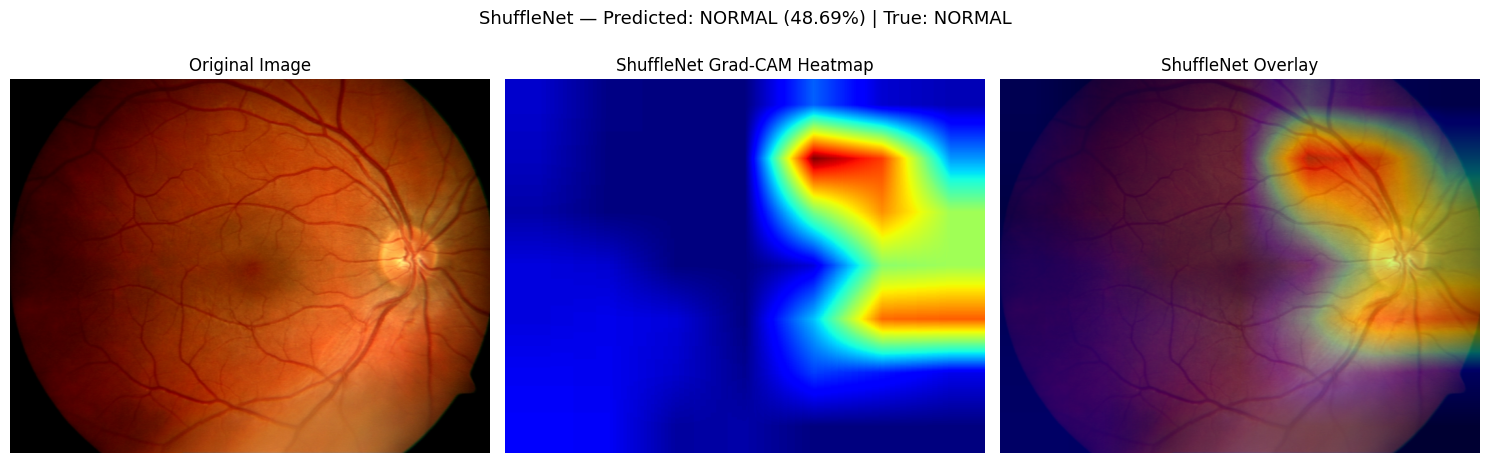

In [ ]:
gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def forward_hook(module, input, output):
    activations.append(output)

# register hooks and save handles so they can be removed after
target_layer = ensemble.model3.conv5[0]
forward_handle  = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# prepare image
original_image = Image.open(image_path).convert('RGB')
input_tensor = test_transform(original_image).unsqueeze(0).to(device)
input_tensor.requires_grad_()

# run only through shufflenet
ensemble.model3.eval()
output = torch.softmax(ensemble.model3(input_tensor), dim=1)
pred_idx = output.argmax(dim=1).item()

# print shufflenet probabilities
print("ShuffleNet Class Probabilities:")
for label, prob in zip(LABEL_COLS, output[0].cpu().detach().numpy()):
    marker = " <-- Predicted" if label == LABEL_COLS[pred_idx] else ""
    print(f"  {label:<35} {prob*100:.2f}%{marker}")
print(f"\nTrue Label: {true_label}")

# backward pass
ensemble.model3.zero_grad()
output[0, pred_idx].backward()

# remove hooks immediately after use
forward_handle.remove()
backward_handle.remove()

# generate heatmap
gradient = gradients[0].cpu().detach().numpy()[0]
activation = activations[0].cpu().detach().numpy()[0]

weights = gradient.mean(axis=(1, 2))
heatmap = np.sum(weights[:, None, None] * activation, axis=0)
heatmap = np.maximum(heatmap, 0)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# resize heatmap to image size
heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize(
    original_image.size, Image.BILINEAR)) / 255.0

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image)
axes[0].axis('off')
axes[0].set_title('Original Image')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].axis('off')
axes[1].set_title('ShuffleNet Grad-CAM Heatmap')

axes[2].imshow(original_image)
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
axes[2].axis('off')
axes[2].set_title('ShuffleNet Overlay')

fig.suptitle(f'ShuffleNet — Predicted: {LABEL_COLS[pred_idx]} ({output[0][pred_idx].item()*100:.2f}%) | True: {true_label}', fontsize=13)
plt.tight_layout()
plt.show()

# General evaluation

In [ ]:
# loading the dataframe and creating dataloader
IMAGE_COL = 'image_path'
#LABEL_COLS = ['NORMAL', 'DR', 'OTHER', 'ARMD', 'HTR', 'MYA']

# same transformation as the training set
test_transform = transforms.Compose([
    transforms.Lambda(crop_black_borders),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# adjust the test_df.head(50) to test_df for the full test set
dataset = ImagePathDataset(test_df.head(50), image_col=IMAGE_COL, label_cols=LABEL_COLS, transform=test_transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ensemble.to(device)
ensemble.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        print("1")
        outputs = ensemble(inputs)
        print("2")
        preds = outputs.argmax(dim=1).cpu()

        print("added")
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(outputs.cpu().numpy())

accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
print(f'Ensemble Accuracy: {accuracy:.2f}%')
print(classification_report(all_labels, all_preds,
                             labels=list(range(len(LABEL_COLS))),  # force all 8 classes
                             target_names=LABEL_COLS,
                             zero_division=0))  # avoiding warnings for classes with no predictions
# classification report for precision, recall f1 score etc

1
2
added
1
2
added
Ensemble Accuracy: 12.00%
                                  precision    recall  f1-score   support

                          NORMAL       1.00      0.12      0.22        49
                    HYPERTENSION       0.00      0.00      0.00         0
                        CATARACT       0.00      0.00      0.00         0
AGE_RELATED_MACULAR_DEGENERATION       0.00      0.00      0.00         0
                        GLAUCOMA       0.00      0.00      0.00         0
                          MYOPIA       0.00      0.00      0.00         0
            DIABETIC_RETINOPATHY       0.00      0.00      0.00         1
                  OTHER_DISEASES       0.00      0.00      0.00         0

                        accuracy                           0.12        50
                       macro avg       0.12      0.02      0.03        50
                    weighted avg       0.98      0.12      0.21        50



# AUROC curve

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

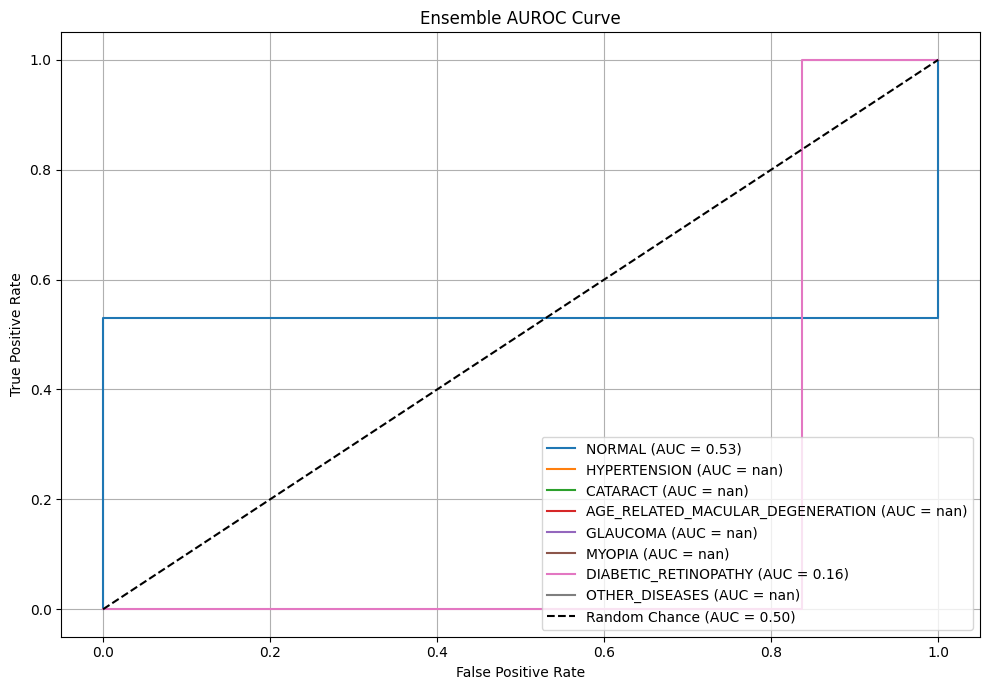

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# convert to numpy array
all_probs_np = np.array(all_probs)

# make the labels binary for AUROC
all_labels_bin = label_binarize(all_labels, classes=list(range(len(LABEL_COLS))))

plt.figure(figsize=(10, 7))

# plot AUROC curve per class
for i, class_name in enumerate(LABEL_COLS):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs_np[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

# plot random chance baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble AUROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()